<a href="https://colab.research.google.com/github/sathwik10126/NLP/blob/Main/2403A52245_NLP_Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import nltk
import spacy
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords


**Extractracting Text in Tweet**

In [80]:
df = pd.read_csv('/content/Tweets.csv')
df.head()


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [81]:
text_data = df['text']
print(text_data.head())


0                  @VirginAmerica What @dhepburn said.
1    @VirginAmerica plus you've added commercials t...
2    @VirginAmerica I didn't today... Must mean I n...
3    @VirginAmerica it's really aggressive to blast...
4    @VirginAmerica and it's a really big bad thing...
Name: text, dtype: object


**Cleaning Text Data**

In [82]:
def clean_text(text):
    text = re.sub(r'http\S+|www\S+', '', str(text))
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^A-Za-z\s]', '', text)
    return text.lower()

df['cleaned_text'] = df['text'].apply(clean_text)

df[['text', 'cleaned_text']].head()

,text,cleaned_text
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experienc...
2,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take anothe...
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious ente...
4,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it


**Visulaizing Hashtags**

In [83]:
def extract_hashtags(tweet):
    hashtags = re.findall(r'#\w+', tweet)
    return hashtags

all_hashtags = df['text'].apply(extract_hashtags)
print(all_hashtags.head())

0    []
1    []
2    []
3    []
4    []
Name: text, dtype: object


In [84]:
from collections import Counter

flat_hashtags = [hashtag for sublist in all_hashtags for hashtag in sublist]
hashtag_frequencies = Counter(flat_hashtags)

hashtag_freq_df = pd.DataFrame(hashtag_frequencies.items(), columns=['Hashtag', 'Frequency']).sort_values(by='Frequency', ascending=False)

print(hashtag_freq_df.head(10))

                 Hashtag  Frequency
778  #DestinationDragons         75
4                  #fail         57
124             #jetblue         35
172      #UnitedAirlines         35
32      #customerservice         34
232       #usairwaysfail         26
67     #AmericanAirlines         24
63         #disappointed         22
132              #avgeek         19
227          #badservice         19


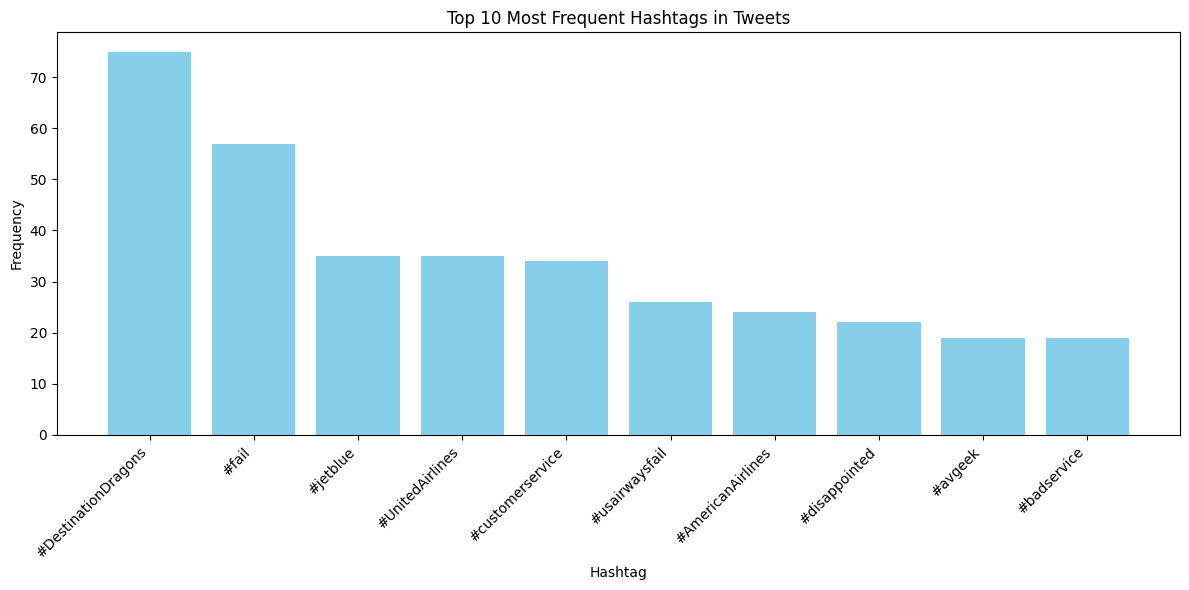

In [85]:
plt.figure(figsize=(12, 6))
plt.bar(hashtag_freq_df['Hashtag'].head(10), hashtag_freq_df['Frequency'].head(10), color='skyblue')
plt.xlabel('Hashtag')
plt.ylabel('Frequency')
plt.title('Top 10 Most Frequent Hashtags in Tweets')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Word Tokenization**

In [86]:
nltk.download('punkt')

df['tokens'] = df['cleaned_text'].apply(word_tokenize)

df[['cleaned_text', 'tokens']].head()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,cleaned_text,tokens
0,what said,"[what, said]"
1,plus youve added commercials to the experienc...,"[plus, youve, added, commercials, to, the, exp..."
2,i didnt today must mean i need to take anothe...,"[i, didnt, today, must, mean, i, need, to, tak..."
3,its really aggressive to blast obnoxious ente...,"[its, really, aggressive, to, blast, obnoxious..."
4,and its a really big bad thing about it,"[and, its, a, really, big, bad, thing, about, it]"


In [87]:
import spacy

nlp = spacy.load("en_core_web_sm")


df['tokens'] = df['cleaned_text'].apply(
    lambda text: [token.text for token in nlp(text)]
)
df[['cleaned_text', 'tokens']].head()

,cleaned_text,tokens
0,what said,"[ , what, , said]"
1,plus youve added commercials to the experienc...,"[ , plus, you, ve, added, commercials, to, the..."
2,i didnt today must mean i need to take anothe...,"[ , i, did, nt, today, must, mean, i, need, to..."
3,its really aggressive to blast obnoxious ente...,"[ , its, really, aggressive, to, blast, obnoxi..."
4,and its a really big bad thing about it,"[ , and, its, a, really, big, bad, thing, abou..."


**Stop word removal**

In [88]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['tokens_no_stopwords'] = df['tokens'].apply(remove_stopwords)

df[['tokens', 'tokens_no_stopwords']].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,tokens,tokens_no_stopwords
0,"[ , what, , said]","[ , , said]"
1,"[ , plus, you, ve, added, commercials, to, the...","[ , plus, added, commercials, experience, tacky]"
2,"[ , i, did, nt, today, must, mean, i, need, to...","[ , nt, today, must, mean, need, take, another..."
3,"[ , its, really, aggressive, to, blast, obnoxi...","[ , really, aggressive, blast, obnoxious, ente..."
4,"[ , and, its, a, really, big, bad, thing, abou...","[ , really, big, bad, thing]"


In [89]:
import spacy

nlp = spacy.load("en_core_web_sm")


stop_words = nlp.Defaults.stop_words

def remove_stopwords_spacy(tokens):
    return [token for token in tokens if token.lower() not in stop_words]


df['tokens_no_stopwords'] = df['tokens'].apply(remove_stopwords_spacy)


df[['tokens', 'tokens_no_stopwords']].head()

,tokens,tokens_no_stopwords
0,"[ , what, , said]","[ , , said]"
1,"[ , plus, you, ve, added, commercials, to, the...","[ , plus, ve, added, commercials, experience, ..."
2,"[ , i, did, nt, today, must, mean, i, need, to...","[ , nt, today, mean, need, trip]"
3,"[ , its, really, aggressive, to, blast, obnoxi...","[ , aggressive, blast, obnoxious, entertainmen..."
4,"[ , and, its, a, really, big, bad, thing, abou...","[ , big, bad, thing]"


**Lemmatization**

In [90]:
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['nltk_lemmatized_tokens'] = df['tokens_no_stopwords'].apply(lemmatize_tokens)
print(df[['tokens_no_stopwords', 'nltk_lemmatized_tokens']].head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                 tokens_no_stopwords  \
0                                       [ ,  , said]   
1  [ , plus, ve, added, commercials, experience, ...   
2                   [ , nt, today, mean, need, trip]   
3  [ , aggressive, blast, obnoxious, entertainmen...   
4                               [ , big, bad, thing]   

                              nltk_lemmatized_tokens  
0                                       [ ,  , said]  
1  [ , plus, ve, added, commercial, experience, t...  
2                   [ , nt, today, mean, need, trip]  
3  [ , aggressive, blast, obnoxious, entertainmen...  
4                               [ , big, bad, thing]  


In [91]:
nlp = spacy.load("en_core_web_sm")

def spacy_lemmatize(tokens):
    doc = nlp(" ".join(tokens))
    return [token.lemma_ for token in doc]

df['lemmatized_tokens'] = df['tokens_no_stopwords'].apply(spacy_lemmatize)

df[['tokens_no_stopwords', 'lemmatized_tokens']].head()


,tokens_no_stopwords,lemmatized_tokens
0,"[ , , said]","[ , say]"
1,"[ , plus, ve, added, commercials, experience, ...","[ , plus, ve, add, commercial, experience, ta..."
2,"[ , nt, today, mean, need, trip]","[ , not, today, mean, need, trip]"
3,"[ , aggressive, blast, obnoxious, entertainmen...","[ , aggressive, blast, obnoxious, entertainme..."
4,"[ , big, bad, thing]","[ , big, bad, thing]"


**Rejoining Processed Tweet and Corresponding Label**

In [96]:
df['final_processed_text'] = df['lemmatized_tokens'].apply(lambda x: " ".join(x))


final_df = df[['final_processed_text', 'airline_sentiment']]
(final_df.head())

,final_processed_text,airline_sentiment
0,say,neutral
1,plus ve add commercial experience tacky,positive
2,not today mean need trip,neutral
3,aggressive blast obnoxious entertainment gu...,negative
4,big bad thing,negative


**complete pipeline**

In [94]:
def tweet_nlp_pipeline(text):
    text = clean_text(text)
    tokens = word_tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = spacy_lemmatize(tokens)
    return " ".join(tokens)

df['processed_tweet'] = df['text'].apply(tweet_nlp_pipeline)
(df[['processed_tweet', 'airline_sentiment']].head())

,processed_tweet,airline_sentiment
0,say,neutral
1,plus you ve add commercial experience tacky,positive
2,do not today mean need trip,neutral
3,aggressive blast obnoxious entertainment guest...,negative
4,big bad thing,negative
